# Environment Setup

In [1]:
%pip install xgboost

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Data Preprocessing
1. Update Height where Height = 0
2. Find rows where Minutes > Appearances*90 (a match typically lasts 90 minutes)
3. Treat duplicated instances
4. Replace "Á" with "A"

In [3]:
# Open the CSV file
df = pd.read_csv('original-dataset.csv')

#Check the structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Minutes       3262 non-null   int64  
 1   Injured       3262 non-null   int64  
 2   Recovering    3262 non-null   int64  
 3   Age           3262 non-null   int64  
 4   Height        3262 non-null   float64
 5   Name          3262 non-null   object 
 6   Position      3262 non-null   object 
 7   Appearances   3262 non-null   int64  
 8   Assists       3262 non-null   int64  
 9   Passes        3262 non-null   int64  
 10  Yellow cards  3262 non-null   int64  
 11  Red cards     3262 non-null   int64  
 12  Fouls         3262 non-null   int64  
 13  Tackles       3262 non-null   int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 356.9+ KB


## Height
As there are a small number of records with Height = 0, I manually searched for their heights online and updated the dataset accordingly.

In [4]:
# Records where Height = 0
zero_height = df[df['Height'] == 0]
zero_height["Name"].unique()

array(['Thibaut Courtois', 'Matt Macey', 'Per Mertesacker',
       'Fraser Forster', 'Mark Schwarzer', 'Robert Huth',
       'Philipp Wollscheid', 'Peter Crouch', 'Gerhard Tremmel',
       'Jay Fulton', 'Costel Pantilimon', 'Connor Dymond',
       'Alexander Manninger', 'Josh Clackstone', 'Sam Hughes',
       'Harry Souttar', 'Rayhaan Tulloch', 'Joe Powell', 'Dan Burn',
       'Alireza Jahanbakhsh', 'Aaron Rowe', 'Leighton Clarkson',
       'Lloyd Kelly', 'Lovre Kalinic', 'Lewis Richardson', 'Archie Mair',
       'Alfie Devine', 'Reece Welch', 'Kyle John', 'Isaac Price',
       'Shane Flynn', 'Vontae Daley-Campbell', 'Sidnei Tavares',
       'Tawanda Maswanhise', 'Jamal Baptiste', 'Caleb Watts',
       'Ryan Finnigan', 'Tim Iroegbunam', 'Cheikh Diaby'], dtype=object)

In [5]:
# Set Height manually

df.loc[df['Name'] == 'Aaron Rowe', 'Height'] = 1.68
df.loc[df['Name'] == 'Josh Clackstone', 'Height'] = 1.71
df.loc[df['Name'] == 'Caleb Watts', 'Height'] = 1.73
# Set Height for players with names in the list
df.loc[df['Name'].isin(['Cheikh Diaby', 'Connor Dymond', 
                      'Leighton Clarkson']), 'Height'] = 1.75
df.loc[df['Name'] == 'Kyle John', 'Height'] = 1.76
df.loc[df['Name'].isin(['Joe Powell', 'Lewis Richardson',
                      'Rayhaan Tulloch']), 'Height'] = 1.78
df.loc[df['Name'].isin(['Charlie Patino', 'Tawanda Maswanhise']), 'Height'] = 1.80
df.loc[df['Name'].isin(['Alireza Jahanbakhsh', 'Shane Flynn']), 'Height'] = 1.81
df.loc[df['Name'].isin(['Tim Iroegbunam', 'Vontae Daley-Campbell']), 'Height'] = 1.83
df.loc[df['Name'].isin(['Jay Fulton','Ryan Finnigan']), 'Height'] = 1.85
df.loc[df['Name'] == 'Sam Hughes', 'Height'] = 1.87
df.loc[df['Name'].isin(['Isaac Price','Sidnei Tavares']), 'Height'] = 1.88
df.loc[df['Name'].isin(['Alexander Manninger', 'Alfie Devine', 
                      'Lloyd Kelly']), 'Height'] = 1.89
df.loc[df['Name'] == 'Gerhard Tremmel', 'Height'] = 1.90
df.loc[df['Name'].isin(['Jamal Baptiste', 'Robert Huth']), 'Height'] = 1.91
df.loc[df['Name'].isin(['Mark Schwarzer','Philipp Wollscheid']), 'Height'] = 1.94
df.loc[df['Name'] == 'Reece Welch', 'Height'] = 1.97
df.loc[df['Name'].isin(['Archie Mair', 'Harry Souttar']), 'Height'] = 1.98
df.loc[df['Name'] == 'Per Mertesacker', 'Height'] = 1.99
df.loc[df['Name'] == 'Thibaut Courtois', 'Height'] = 2.00
df.loc[df['Name'].isin(['Dan Burn', 'Fraser Forster', 
                      'Lovre Kalinic', 'Matt Macey',
                      'Peter Crouch']), 'Height'] = 2.01
df.loc[df['Name'] == 'Costel Pantilimon', 'Height'] = 2.03

## Minutes and Appearances
Two players had strange-looking Minutes as compared to Appearances. By manually checking on Transfermarkt, their data were mistaken for Egyptian Premier League. Two such instances were removed.

In [6]:
# Show instances where Minutes > 90 * Appearances
over_minutes = df[df['Minutes'] > 90 * df['Appearances']]
over_minutes

,Minutes,Injured,Recovering,Age,Height,Name,Position,Appearances,Assists,Passes,Yellow cards,Red cards,Fouls,Tackles
2063,1385,1,0,21,1.83,Ramadan Sobhi,Midfielder,4,0,43,0,0,0,1
2469,1350,0,0,28,1.93,Ali Gabr,Defender,0,0,0,0,0,0,0


In [7]:
# Remove rows where index = 2063, 2469
df = df.drop(index=[2063, 2469])

## Duplicates

In [8]:
# Check rows where Name, Age are duplicated
duplicates = df[df.duplicated(subset=['Name', 'Age'], keep=False)]
duplicates

,Minutes,Injured,Recovering,Age,Height,Name,Position,Appearances,Assists,Passes,Yellow cards,Red cards,Fouls,Tackles
28,98,0,0,21,1.80,Nathan Aké,Defender,12,1,405,1,0,4,22
29,733,0,0,21,1.80,Nathan Aké,Defender,12,1,405,1,0,4,22
57,1912,0,0,24,1.90,Ruben Loftus-Cheek,Midfielder,31,0,726,3,0,29,25
58,61,0,0,24,1.90,Ruben Loftus-Cheek,Midfielder,31,0,726,3,0,29,25
68,980,1,1,24,1.77,Victor Moses,Midfielder,21,2,280,0,0,17,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2748,0,1,1,23,1.78,Diogo Jota,Forward,19,0,426,2,0,25,12
2907,717,0,1,25,1.74,Takumi Minamino,Forward,19,0,387,1,0,11,11
2908,286,0,1,25,1.74,Takumi Minamino,Forward,19,0,387,1,0,11,11
2923,590,0,0,18,1.63,Tariq Lamptey,Defender,9,1,178,2,0,13,9


In [9]:
# Define how to aggregate each column
agg_dict = {
    'Minutes': 'sum',
    'Appearances': 'first',
    'Assists': 'first',
    'Passes': 'first',
    'Yellow cards': 'first',
    'Red cards': 'first',
    'Fouls': 'first',
    'Tackles': 'first',
    'Age': 'first',
    'Height': 'first',
    'Injured': 'first',
    'Recovering': 'first',
    'Position': 'first'
}

df = df.groupby(['Name', 'Age'], as_index=False).agg(agg_dict)

## Replace special characters

In [10]:
# Replace ' in Name with a blankspace
df['Name'] = df['Name'].str.replace("'", " ")

In [11]:
# Replace Á in Name with A
df['Name'] = df['Name'].str.replace("Á", "A")

# Data Transformation
1. One-hot encoding
2. Drop Name attribute
3. Feature selection
4. Data scaling

In [12]:
# One-hot encode Position column
df = pd.get_dummies(df, columns=['Position'], drop_first=True)

# Drop nominal attribute
df = df.drop(columns=['Name'])          

<Axes: title={'center': 'Pearson Correlation Matrix'}>

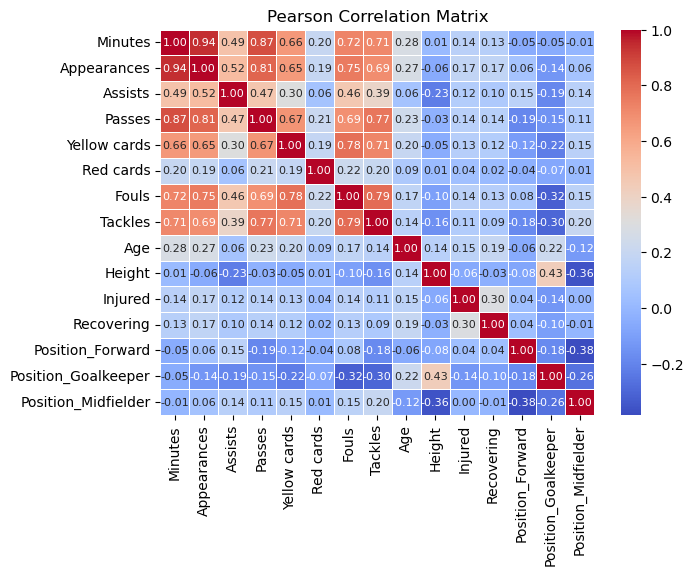

In [13]:
# Feature Selection

plt.figure(figsize=(7, 5))
plt.title("Pearson Correlation Matrix")
pearson_matrix = df.corr(method='pearson')
sns.heatmap(pearson_matrix, 
            annot=True,
            annot_kws={"size": 8},
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

In [14]:
# 80-20 train-test split
df_selected = df[['Minutes', 'Appearances', 'Age', 'Recovering', 'Injured']]
X = df_selected.drop(columns=['Injured'])
y = df_selected['Injured']
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Data Mining

## Baseline model: Logistic Regression

In [15]:
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced'))
])

y_pred = logistic_model.fit(X_train, Y_train).predict(X_test)
print('Macro Avg F1-score: %.1f' % (100*f1_score(Y_test, y_pred, average='macro')))

Macro Avg F1-score: 64.0


In [16]:
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

[[277  91]
 [129 142]]
              precision    recall  f1-score   support

           0       0.68      0.75      0.72       368
           1       0.61      0.52      0.56       271

    accuracy                           0.66       639
   macro avg       0.65      0.64      0.64       639
weighted avg       0.65      0.66      0.65       639



## XGBoost

In [18]:
# XGBoost model with default hyperparameters
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

y_pred = xgb_pipeline.fit(X_train, Y_train).predict(X_test)
print('Macro Avg F1-score: %.1f' % (100*f1_score(Y_test, y_pred, average='macro')))

Macro Avg F1-score: 62.8


In [19]:
# Stratified K-Fold ensures class balance in each fold
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'roc_auc':             'roc_auc',
    'accuracy':            'accuracy',
    'precision_weighted':  'precision_weighted',
    'recall_weighted':     'recall_weighted',
    'f1_weighted':         'f1_weighted'
}

results = cross_validate(
    xgb_pipeline,
    X_train,
    Y_train,
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=False
)

# Test Set Results
xgb_pipeline.fit(X_train, Y_train)
predictions = xgb_pipeline.predict(X_test)
y_prob      = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\nTest Set Results")
print("=" * 40)
print(classification_report(Y_test, predictions))
print(f"ROC-AUC: {roc_auc_score(Y_test, y_prob):.4f}")


Test Set Results
              precision    recall  f1-score   support

           0       0.69      0.66      0.68       368
           1       0.56      0.60      0.58       271

    accuracy                           0.63       639
   macro avg       0.63      0.63      0.63       639
weighted avg       0.64      0.63      0.63       639

ROC-AUC: 0.6771


In [21]:
# Hyperparameter grid
param_grid_xgb = {
    "xgb__n_estimators":     [100, 200, 300],
    "xgb__max_depth":        [3, 5, 7],
    "xgb__learning_rate":    [0.01, 0.1, 0.2],
    "xgb__subsample":        [0.7, 1.0],
    "xgb__colsample_bytree": [0.7, 1.0],
}
 
grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring=scoring,
    cv=cv_strategy,
    refit="recall_weighted",  # metric used to pick the best model
    n_jobs=-1,
    verbose=1,
)
 
grid_xgb.fit(X_train, Y_train)
 
print(f"Best Parameters: {grid_xgb.best_params_}")
print(f"Best CV Recall:  {grid_xgb.best_score_:.4f}")

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
Best Parameters: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 5, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
Best CV Recall:  0.6643


In [22]:
# Best CV Scores 
print("\nBest CV Scores (10-Fold)")
print("=" * 40)
results = grid_xgb.cv_results_
best_idx = grid_xgb.best_index_

for metric in scoring.keys():
    mean = results[f'mean_test_{metric}'][best_idx]
    std  = results[f'std_test_{metric}'][best_idx]
    print(f"  {metric:25s}: {mean:.4f} ± {std:.4f}")

# Final Evaluation on Test Set
best_xgb = grid_xgb.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("\nTest Set Results")
print("=" * 40)
print(classification_report(Y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(Y_test, y_prob):.4f}")


Best CV Scores (10-Fold)
  roc_auc                  : 0.7355 ± 0.0391
  accuracy                 : 0.6643 ± 0.0396
  precision_weighted       : 0.6654 ± 0.0421
  recall_weighted          : 0.6643 ± 0.0396
  f1_weighted              : 0.6594 ± 0.0380

Test Set Results
              precision    recall  f1-score   support

           0       0.69      0.80      0.74       368
           1       0.65      0.52      0.58       271

    accuracy                           0.68       639
   macro avg       0.67      0.66      0.66       639
weighted avg       0.67      0.68      0.67       639

ROC-AUC: 0.7340


## Random Forest

In [23]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

y_pred = xgb_pipeline.fit(X_train, Y_train).predict(X_test)
print('Macro Avg F1-score: %.1f' % (100*f1_score(Y_test, y_pred, average='macro')))

Macro Avg F1-score: 62.8


In [24]:
results = cross_validate(
    rf_pipeline,
    X_train,
    Y_train,
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=False
)

# CV Results
print("RF Baseline — 10-Fold CV Results")
print("=" * 40)
for metric in scoring.keys():
    mean = results[f'test_{metric}'].mean()
    std  = results[f'test_{metric}'].std()
    print(f"  {metric:25s}: {mean:.4f} ± {std:.4f}")

RF Baseline — 10-Fold CV Results
  roc_auc                  : 0.6766 ± 0.0327
  accuracy                 : 0.6213 ± 0.0313
  precision_weighted       : 0.6216 ± 0.0315
  recall_weighted          : 0.6213 ± 0.0313
  f1_weighted              : 0.6203 ± 0.0310


In [25]:
# Test Set Results
rf_pipeline.fit(X_train, Y_train)
predictions = rf_pipeline.predict(X_test)
y_prob      = rf_pipeline.predict_proba(X_test)[:, 1]

print("\nTest Set Results")
print("=" * 40)
print(classification_report(Y_test, predictions))
print(f"ROC-AUC: {roc_auc_score(Y_test, y_prob):.4f}")


Test Set Results
              precision    recall  f1-score   support

           0       0.67      0.68      0.68       368
           1       0.56      0.55      0.55       271

    accuracy                           0.63       639
   macro avg       0.62      0.62      0.62       639
weighted avg       0.62      0.63      0.63       639

ROC-AUC: 0.6824


In [27]:
# Hyperparameter grid
param_grid = {
    "rf__n_estimators":      [100, 200, 300],
    "rf__max_depth":         [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf":  [1, 2, 4],
    "rf__max_features":      ["sqrt", "log2"],
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit='recall_weighted'
)

grid_rf.fit(X_train, Y_train)
print(f"Best Parameters:  {grid_rf.best_params_}")
print(f"Best CV Recall:  {grid_rf.best_score_:.4f}")

Fitting 10 folds for each of 216 candidates, totalling 2160 fits
Best Parameters:  {'rf__max_depth': 5, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best CV Recall:  0.6538


In [28]:
# Best CV Scores 
print("\nBest CV Scores (10-Fold)")
print("=" * 40)
results = grid_rf.cv_results_
best_idx = grid_rf.best_index_

for metric in scoring.keys():
    mean = results[f'mean_test_{metric}'][best_idx]
    std  = results[f'std_test_{metric}'][best_idx]
    print(f"  {metric:25s}: {mean:.4f} ± {std:.4f}")

# Final Evaluation on Test Set
best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nTest Set Results")
print("=" * 40)
print(classification_report(Y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(Y_test, y_prob):.4f}")


Best CV Scores (10-Fold)
  roc_auc                  : 0.7289 ± 0.0321
  accuracy                 : 0.6538 ± 0.0274
  precision_weighted       : 0.6744 ± 0.0260
  recall_weighted          : 0.6538 ± 0.0274
  f1_weighted              : 0.6518 ± 0.0285

Test Set Results
              precision    recall  f1-score   support

           0       0.77      0.62      0.68       368
           1       0.59      0.75      0.66       271

    accuracy                           0.67       639
   macro avg       0.68      0.68      0.67       639
weighted avg       0.69      0.67      0.67       639

ROC-AUC: 0.7417


## Support Vector Machine

In [29]:
# SVM model with default hyperparameters
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        random_state=42,
        probability=True,
        class_weight="balanced"
    ))
])

y_pred = svm_pipeline.fit(X_train, Y_train).predict(X_test)
print('Macro Avg F1-score: %.1f' % (100*f1_score(Y_test, y_pred, average='macro')))

Macro Avg F1-score: 66.3


In [30]:
# Cross-validation results
results_svm = cross_validate(
    svm_pipeline,
    X_train,
    Y_train,
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=False
)

# CV Results
print("SVM Baseline — 10-Fold CV Results")
print("=" * 40)
for metric in scoring.keys():
    mean = results_svm[f'test_{metric}'].mean()
    std  = results_svm[f'test_{metric}'].std()
    print(f"  {metric:25s}: {mean:.4f} ± {std:.4f}")

SVM Baseline — 10-Fold CV Results
  roc_auc                  : 0.7189 ± 0.0247
  accuracy                 : 0.6561 ± 0.0233
  precision_weighted       : 0.6666 ± 0.0246
  recall_weighted          : 0.6561 ± 0.0233
  f1_weighted              : 0.6563 ± 0.0232


In [31]:
# Test Set Results
svm_pipeline.fit(X_train, Y_train)
predictions = svm_pipeline.predict(X_test)
y_prob      = svm_pipeline.predict_proba(X_test)[:, 1]

print("\nTest Set Results")
print("=" * 40)
print(classification_report(Y_test, predictions))
print(f"ROC-AUC: {roc_auc_score(Y_test, y_prob):.4f}")


Test Set Results
              precision    recall  f1-score   support

           0       0.74      0.65      0.69       368
           1       0.59      0.69      0.63       271

    accuracy                           0.67       639
   macro avg       0.66      0.67      0.66       639
weighted avg       0.68      0.67      0.67       639

ROC-AUC: 0.7174


In [32]:
param_grid = {
    'svc__C': [0.1, 1, 10, 100, 1000], 
	'svc__gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
	'svc__kernel': ['rbf']} 

gridsvm = GridSearchCV(
    estimator=svm_pipeline, 
    param_grid = param_grid,
    scoring=scoring,
    cv=cv_strategy, 
    n_jobs=-1,
    verbose=1,
    refit='recall_weighted'
)
                
gridsvm.fit(X_train, Y_train)

Fitting 10 folds for each of 25 candidates, totalling 250 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc',
                                        SVC(class_weight='balanced',
                                            probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'svc__C': [0.1, 1, 10, 100, 1000],
                         'svc__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'svc__kernel': ['rbf']},
             refit='recall_weighted',
             scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted',
                      'precision_weighted': 'precision_weighted',
                      'recall_weighted': 'recall_weighted',
                      'roc_auc': 'roc_auc'},
             verbose=1)

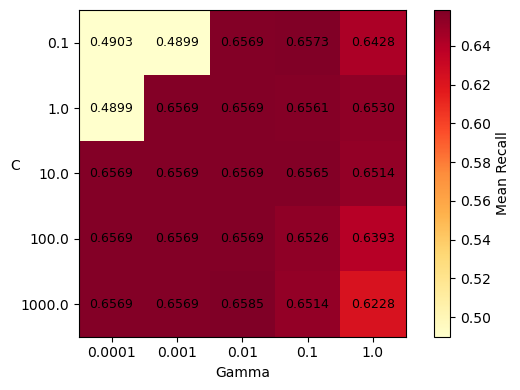

In [34]:
# Extract CV results
cv_results = pd.DataFrame(gridsvm.cv_results_)

# Pivot to get mean recall for each C and gamma combination
pivot = cv_results.pivot_table(
    index='param_svc__C',
    columns='param_svc__gamma',
    values='mean_test_recall_weighted'
)

# Plot heatmap
plt.figure(figsize=(6, 4))
plt.imshow(pivot, interpolation='nearest', cmap='YlOrRd')
plt.colorbar(label='Mean Recall')

# Axis labels
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=0)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('Gamma')
plt.ylabel('C', rotation=0)

# Annotate each cell with the score
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f'{pivot.iloc[i, j]:.4f}',
                 ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [35]:
best_svm = gridsvm.best_estimator_
grid_predictions = gridsvm.predict(X_test)
print(classification_report(Y_test, grid_predictions))
print(f"ROC-AUC Score: {roc_auc_score(Y_test, grid_predictions):.4f}")

              precision    recall  f1-score   support

           0       0.74      0.59      0.66       368
           1       0.56      0.72      0.63       271

    accuracy                           0.64       639
   macro avg       0.65      0.65      0.64       639
weighted avg       0.66      0.64      0.64       639

ROC-AUC Score: 0.6528
